<a href="https://colab.research.google.com/github/VijayReddy-07/TASK---2-Titanic-Survival-Analysis/blob/main/TITANIC_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TITANIC DATA ANALYSIS - TASK 2


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Dataset
df = pd.read_csv('Titanic-Dataset.csv')

print("Dataset Loaded Successfully!")
print(df.head())


Dataset Loaded Successfully!
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

 DATA EXPLORATION

In [4]:
print("\nDataset Shape:")
print(df.shape)



Dataset Shape:
(891, 12)


In [5]:
print("Columns:")
print(df.columns)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


DATA CLEANING

In [7]:
# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)


/tmp/ipykernel_1829/3135688688.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [8]:
# Fill Embarked missing values
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


/tmp/ipykernel_1829/1643442094.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [9]:
# Drop Cabin column (many missing values)
df.drop('Cabin', axis=1, inplace=True)


In [10]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


QUESTION 1
# WHO SURVIVED MORE?

In [11]:
gender_survival = pd.crosstab(df['Sex'], df['Survived'])

print("\nSurvival by Gender:")
print(gender_survival)


Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


 QUESTION 2
# DID PASSENGER CLASS AFFECT SURVIVAL?

In [12]:
class_survival = pd.crosstab(df['Pclass'], df['Survived'])

print("\nSurvival by Passenger Class:")
print(class_survival)


Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


QUESTION 3
# SURVIVAL RATE BY AGE GROUP

In [13]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=bins,
                        labels=labels)

age_survival = df.groupby('AgeGroup')['Survived'].mean()*100

print("\nSurvival Rate by Age Group:")
print(age_survival)


Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


/tmp/ipykernel_1829/528227149.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()*100


VISUALIZATION 1
# SURVIVAL BY GENDER

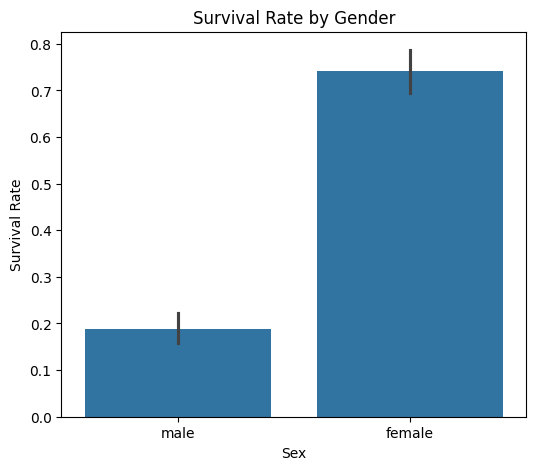

In [14]:
plt.figure(figsize=(6,5))
sns.barplot(x='Sex',
            y='Survived',
            data=df)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()


 VISUALIZATION 2
# SURVIVAL BY CLASS

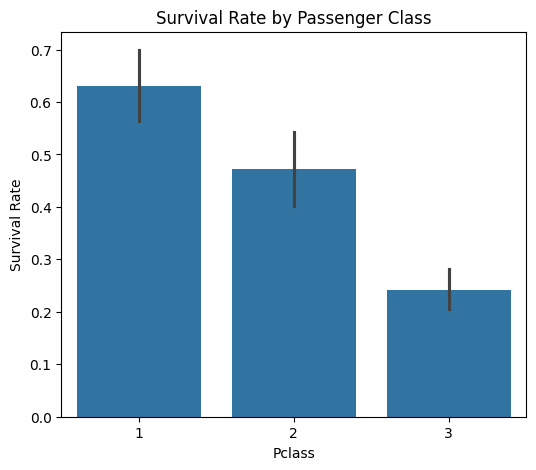

In [15]:
plt.figure(figsize=(6,5))
sns.barplot(x='Pclass',
            y='Survived',
            data=df)

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

VISUALIZATION 3
# AGE DISTRIBUTION


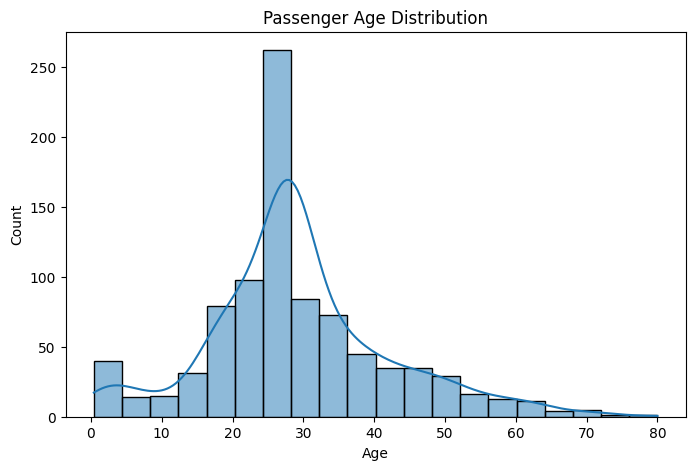

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],
             bins=20,
             kde=True)

plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.show()

VISUALIZATION 4
# HEATMAP

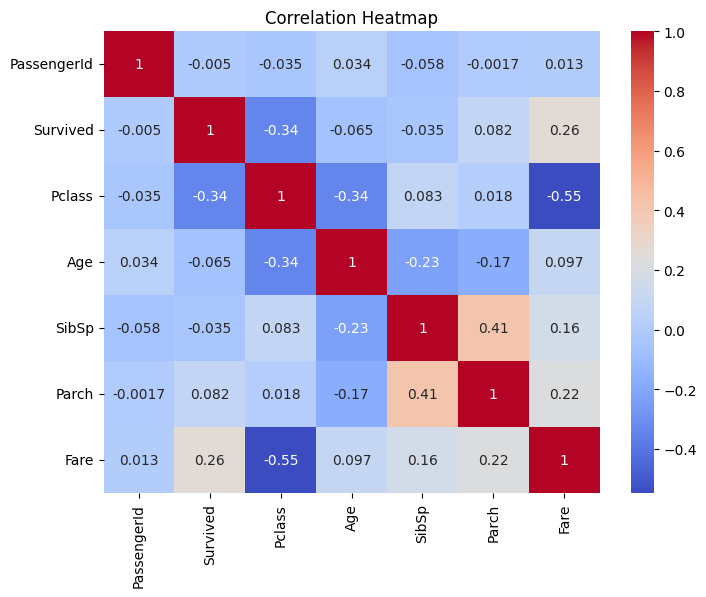

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# FINAL SUMMARY

In [18]:
female_survival = df[df['Sex']=='female']['Survived'].mean()*100
male_survival = df[df['Sex']=='male']['Survived'].mean()*100

print("\n========== SUMMARY ==========")
print(f"Female Survival Rate : {female_survival:.2f}%")
print(f"Male Survival Rate   : {male_survival:.2f}%")
print("\nAge Group Survival Rate:")
print(age_survival)


========== SUMMARY ==========
Female Survival Rate : 74.20%
Male Survival Rate   : 18.89%

Age Group Survival Rate:
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64
